In [2]:
import numpy as np
import seaborn as sns
import pandas as pd
import sys
from pathlib import Path
import astropy.units as u
from matplotlib import pyplot as plt
import corner
import json
from astropy.io import fits
import lmfit
from lmfit.model import save_modelresult


In [3]:
# Parameters
name = "MUSE-M42-H-bin3"
fits_path = "fits_ready/MUSE-M42-H-bin3.fits"


In [4]:
# Loading obs
hdul = fits.open(fits_path)
hdr = hdul[0].header
print(hdul.info())
print(hdr)


Filename: fits_ready/MUSE-M42-H-bin3.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      23   ()      
  1  MOM0          1 ImageHDU         8   (220, 184)   float64   
  2  MOM1          1 ImageHDU         8   (220, 184)   float64   
  3  MASK          1 ImageHDU         8   (220, 184)   uint8   
  4  TABLE         1 BinTableHDU     23   49R x 7C   [D, D, D, D, K, D, D]   
  5  PARAMETERS    1 BinTableHDU     19   3R x 5C   [D, D, D, D, D]   
None
SIMPLE  =                    T / conforms to FITS standard                      BITPIX  =                    8 / array data type                                NAXIS   =                    0 / number of array dimensions                     EXTEND  =                    T                                                  FILE    = 'H_I-6563'           / Fits file name                                 NAME_ID = 'MUSE-M42-H-bin3'    / pipeline identifier                            REG     = 'M 42

In [6]:
hdul[0]

In [7]:
from astropy.table import Table
t = Table.read(fits_path, hdu="PARAMETERS")
df_loaded = t.to_pandas()
df_loaded

,sig2,r0,m,s0,noise
0,8.712282,0.069835,1.197772,0.000660,0.330033
1,0.210084,0.002063,0.020465,0.001098,0.124745
2,0.147357,0.001719,0.025598,0.000428,0.067003


In [10]:
sys.path.append(str(Path().resolve() / 'py_modules')) # 1 level up = project root
#import strucfunc                   
import bfunc
import bplot

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


def get_best_values_from_table(df_params):
    """
    Read best-fit values from a PARAMETERS table.

    Expected table format:
        row 0 = best-fit values
        row 1 = upper uncertainty
        row 2 = lower uncertainty

    Example columns:
        sig2, r0, m, s0, noise
    """
    best = df_params.iloc[0].to_dict()

    # Make sure everything is a plain float
    best = {key: float(value) for key, value in best.items()}

    return best


def get_ci_samples_from_table(df_params, nsamples=100, random_seed=42):
    """
    Generate simple random parameter samples from the confidence intervals.

    This is only for plotting the translucent model curves.

    Assumption:
        row 0 = best value
        row 1 = upper error
        row 2 = lower error
    """
    rng = np.random.default_rng(random_seed)

    values = df_params.iloc[0]
    upper_err = df_params.iloc[1]
    lower_err = df_params.iloc[2]

    samples = []

    for _ in range(nsamples):
        sample = {}

        for par in df_params.columns:
            value = float(values[par])
            err_plus = abs(float(upper_err[par]))
            err_minus = abs(float(lower_err[par]))

            # Asymmetric uncertainty:
            # randomly choose upper or lower side
            if rng.random() < 0.5:
                sampled_value = rng.normal(value, err_minus)
            else:
                sampled_value = rng.normal(value, err_plus)

            # These parameters should not be negative
            if par in ["sig2", "r0", "s0", "noise"]:
                sampled_value = max(sampled_value, 1e-12)

            sample[par] = sampled_value

        samples.append(sample)

    return samples


def strucfunc_plot_from_params(
    df_params,
    r,
    B,
    to_fit,
    source_name,
    suffix,
    box_size,
    large_scale=None,
    yerr=None,
    nsamples=100,
    random_seed=42,
    func=bfunc.bfunc03s,
    func00=bfunc.bfunc00s,
    save=True,
):
    """
    Structure-function plot using a PARAMETERS table instead of lmfit results.

    Parameters
    ----------
    df_params : pandas.DataFrame
        Table loaded from FITS PARAMETERS extension.

    r : array
        Separation values.

    B : array
        Structure-function values.

    to_fit : array of bool
        Boolean mask for points included in the fit.

    source_name : str
        Label shown in the plot.

    suffix : str
        Name used for saving the figure.

    box_size : float
        Physical box size.

    large_scale : optional
        Kept only for compatibility with your old function call.

    yerr : array or None
        Optional error bars for B.

    nsamples : int
        Number of translucent model curves to draw.

    save : bool
        If True, save figure to Imgs/sf-table-{suffix}.pdf.
    """

    r = np.asarray(r)
    B = np.asarray(B)
    to_fit = np.asarray(to_fit, dtype=bool)

    best = get_best_values_from_table(df_params)
    samples = get_ci_samples_from_table(
        df_params,
        nsamples=nsamples,
        random_seed=random_seed,
    )

    whitebox = dict(
        facecolor="white",
        pad=5,
        edgecolor="0.5",
        linewidth=0.5,
    )

    label_kwds = dict(
        ha="center",
        va="center",
        bbox=whitebox,
        zorder=100,
    )

    label_kwds2 = dict(
        ha="left",
        va="center",
        bbox=whitebox,
        zorder=100,
    )

    xmin, xmax = 5e-4 * box_size, 8 * box_size
    ymin, ymax = 5e-3 * np.nanmax(B), 5 * np.nanmax(B)

    xarr = np.logspace(np.log10(xmin), np.log10(xmax), 200)

    fig, ax = plt.subplots(figsize=(10, 10))

    # ------------------------------------------------------------
    # Data
    # ------------------------------------------------------------
    if yerr is None:
        data_points = ax.plot(
            r[to_fit],
            B[to_fit],
            "o",
            zorder=99,
        )
        c_data = data_points[0].get_color()
    else:
        data_points = ax.errorbar(
            r[to_fit],
            B[to_fit],
            yerr=yerr[to_fit],
            fmt="o",
            zorder=99,
        )
        c_data = data_points[0].get_color()

    i_data = bplot.STYLE["data label element"]

    if i_data < len(r):
        ax.annotate(
            "observed",
            (r[i_data], B[i_data]),
            xytext=bplot.STYLE["data label offset"],
            textcoords="offset points",
            color=c_data,
            arrowprops=dict(
                arrowstyle="->",
                color=c_data,
                shrinkB=8,
            ),
            **label_kwds2,
        )

    # ------------------------------------------------------------
    # Best apparent model
    # ------------------------------------------------------------
    Ba = func(xarr, **best)

    line_apparent = ax.plot(xarr, Ba)
    c_apparent = line_apparent[0].get_color()

    ia = bplot.STYLE["model label element"]

    if ia + 1 < len(r):
        xa = 0.5 * (r[ia] + r[ia + 1])
    else:
        xa = xarr[len(xarr) // 4]

    ya = func(xa, **best)

    ax.annotate(
        "model",
        (xa, ya),
        xytext=bplot.STYLE["model label offset"],
        textcoords="offset points",
        color=c_apparent,
        arrowprops=dict(
            arrowstyle="->",
            color=c_apparent,
            shrinkB=8,
        ),
        **label_kwds2,
    )

    # ------------------------------------------------------------
    # Best true model
    # ------------------------------------------------------------
    Bu = func00(
        xarr,
        best["r0"],
        best["sig2"],
        best["m"],
    )

    line_true = ax.plot(
        xarr,
        Bu,
        linestyle="dashed",
    )

    c_true = line_true[0].get_color()

    i_true = bplot.STYLE["true model label element"]
    i_true = min(i_true, len(xarr) - 1)

    ax.annotate(
        "model true",
        (xarr[i_true], Bu[i_true]),
        xytext=bplot.STYLE["true model label offset"],
        textcoords="offset points",
        color=c_true,
        arrowprops=dict(
            arrowstyle="->",
            color=c_true,
            shrinkB=8,
        ),
        **label_kwds,
    )

    # ------------------------------------------------------------
    # Random CI model curves
    # ------------------------------------------------------------
    for sample in samples:
        Bsamp = func(xarr, **sample)

        ax.plot(
            xarr,
            Bsamp,
            alpha=0.05,
            color="orange",
        )

        Busamp = func00(
            xarr,
            sample["r0"],
            sample["sig2"],
            sample["m"],
        )

        ax.plot(
            xarr,
            Busamp,
            alpha=0.05,
            color="g",
        )

    # ------------------------------------------------------------
    # Seeing scale s0
    # ------------------------------------------------------------
    if "s0" in best:
        ax.axvline(
            best["s0"],
            color="k",
            linestyle="dotted",
        )

        ax.annotate(
            r"$s_0$",
            (best["s0"], 1.5 * ymin),
            xytext=(-40, 0),
            textcoords="offset points",
            color="k",
            arrowprops=dict(
                arrowstyle="->",
                color="k",
                shrinkB=2,
            ),
            **label_kwds,
        )

    # ------------------------------------------------------------
    # Box size
    # ------------------------------------------------------------
    ax.axvline(
        box_size,
        color="k",
        linestyle="dotted",
    )

    ax.text(
        box_size,
        1.5 * ymin,
        r"$L$",
        **label_kwds,
    )

    # ------------------------------------------------------------
    # r0
    # ------------------------------------------------------------
    ax.axvline(
        best["r0"],
        color="k",
        linestyle="dashed",
    )

    ax.annotate(
        r"$r_0$",
        (best["r0"], 1.5 * ymin),
        xytext=(40, 20),
        textcoords="offset points",
        color="k",
        arrowprops=dict(
            arrowstyle="->",
            color="k",
            shrinkB=2,
        ),
        **label_kwds,
    )

    # ------------------------------------------------------------
    # sig2
    # ------------------------------------------------------------
    ax.axhline(
        best["sig2"],
        color="k",
        linestyle="dashed",
    )

    ax.text(
        1.5 * xmin,
        best["sig2"],
        r"$\sigma^2$",
        **label_kwds,
    )

    # ------------------------------------------------------------
    # noise
    # ------------------------------------------------------------
    if "noise" in best:
        ax.axhline(
            best["noise"],
            color="k",
            linestyle="dotted",
        )

        if best["noise"] > 0.5 * best["sig2"]:
            ytext = -40
        else:
            ytext = 40

        ax.annotate(
            r"$B_\mathrm{noise}$",
            (1.5 * xmin, best["noise"]),
            xytext=(20, ytext),
            textcoords="offset points",
            color="k",
            arrowprops=dict(
                arrowstyle="->",
                color="k",
                shrinkB=2,
            ),
            **label_kwds,
        )

    # ------------------------------------------------------------
    # Points excluded from fit
    # ------------------------------------------------------------
    if np.any(~to_fit):
        ax.plot(
            r[~to_fit],
            B[~to_fit],
            "o",
            color=c_data,
            mew=3,
            fillstyle="none",
            zorder=99,
        )

        ax.axvspan(
            box_size / 2,
            xmax,
            color="w",
            alpha=0.5,
            zorder=50,
        )

    # ------------------------------------------------------------
    # Final formatting
    # ------------------------------------------------------------
    ax.text(
        np.sqrt(xmin * xmax),
        ymax / 1.5,
        source_name,
        fontsize="large",
        **label_kwds,
    )

    ax.set(
        xscale="log",
        yscale="log",
        xlabel="Separation: $r$ [pc]",
        ylabel=r"Structure function: $B(r)$ [km$^{2}$/s$^{2}$]",
        xlim=[xmin, xmax],
        ylim=[ymin, ymax],
    )

    sns.despine()
    fig.tight_layout()

    if save:
        from pathlib import Path

        figpath = Path("Imgs")
        figpath.mkdir(exist_ok=True, parents=True)

        fig.savefig(figpath / f"sf-table-{suffix}.pdf")

    return fig, ax

In [14]:
with fits.open("fits_ready/" + name + ".fits") as hdul:
    hdr = hdul[0].header
    
#noise    = hdul[0].header['NOISE']
#m3D      = hdul[0].header['M3D']
#ra       = hdul[0].header['RA']
sig      = hdul[0].header['SIG']
sig2     = hdul[0].header['SIG2']
s0       = hdul[0].header['S0']
box_size = hdul[0].header['BOX_SIZE']
pc       = hdul[0].header['PC']
pix      = hdul[0].header['PIX']
line     = hdul[0].header['LINE']
binsize  = hdul[0].header['BINSIZE']

In [15]:
from astropy.table import Table
t = Table.read(fits_path, hdu="TABLE")
data_in = t.to_pandas()


mask = np.array(data_in["N pairs"]) > 0
B        = np.array(data_in['Unweighted B(r)'])[mask]
r        = np.array(10 ** np.array(data_in['log10 r'])* pix * pc)[mask]

In [17]:
# Weights

relative_uncertainty = 0.015
weights = 1.0 / (relative_uncertainty * B)
large_scale = r > 0.3 * box_size
#weights[large_scale] /= 1.5
#weights[:1] /= 2.0

to_fit = r <= 0.5 * box_size
#to_fit = ~large_scale

In [19]:
data = 'argo'

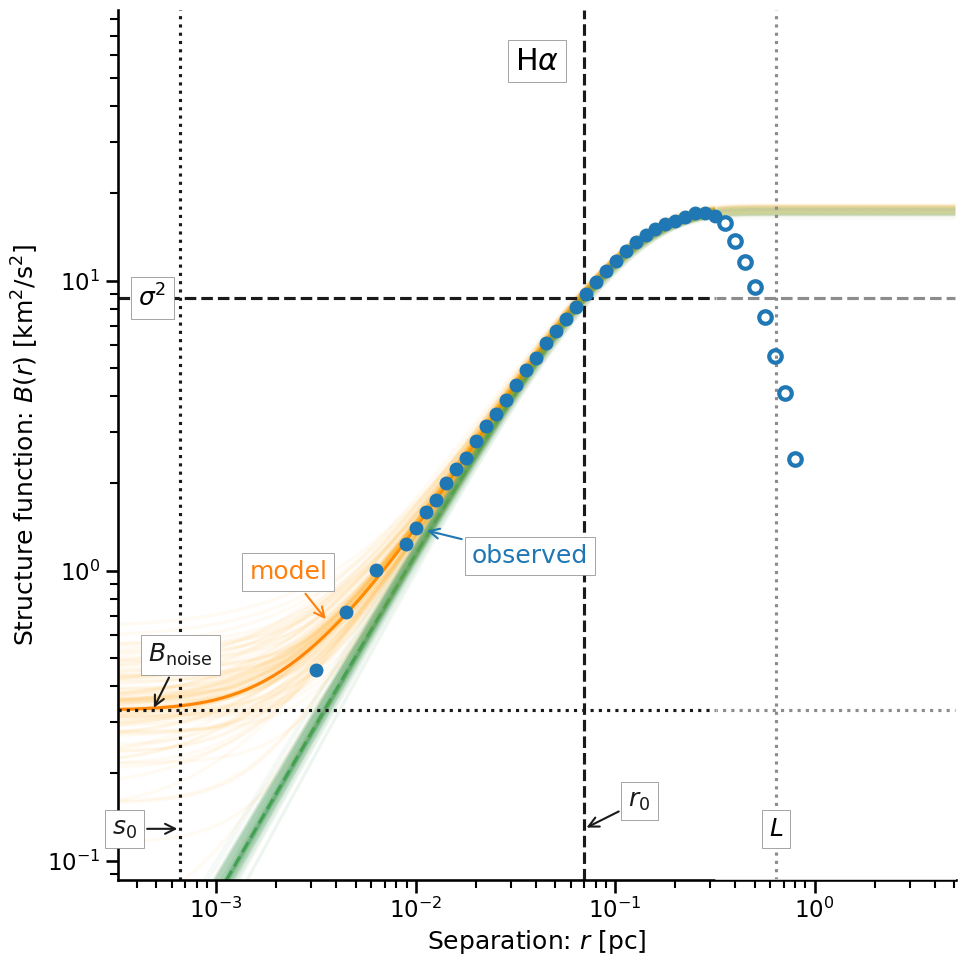

In [20]:
from astropy.table import Table

df_loaded = Table.read(fits_path, hdu="PARAMETERS").to_pandas()

bplot.STYLE["data label element"] = 4
bplot.STYLE["model label element"] = 0
bplot.STYLE["model label offset"] = (-60, 40)
bplot.STYLE["true model label element"] = 10
bplot.STYLE["true model label offset"] = (120, 60)

fig, ax = strucfunc_plot_from_params(
    df_loaded,
    r,
    B,
    to_fit,
    line,
    data,
    box_size,
    large_scale,
)

In [21]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import bplot
import bfunc


def get_best_values_from_table(df_params):
    """
    Read best-fit values from a PARAMETERS table.

    Expected format:
        row 0 = best-fit values
        row 1 = upper errors
        row 2 = lower errors
    """
    best = df_params.iloc[0].to_dict()
    best = {key: float(value) for key, value in best.items()}
    return best


def get_errors_from_table(df_params):
    """
    Read asymmetric errors from a PARAMETERS table.

    Expected format:
        row 0 = best-fit values
        row 1 = upper errors
        row 2 = lower errors
    """
    upper_err = {
        key: abs(float(df_params.iloc[1][key]))
        for key in df_params.columns
    }

    lower_err = {
        key: abs(float(df_params.iloc[2][key]))
        for key in df_params.columns
    }

    return lower_err, upper_err


def spread_span_from_ci(
    ax,
    best,
    lower_err,
    upper_err,
    par,
    orient="h",
    color="m",
    alphas=(0.10, 0.30),
):
    """
    Draw translucent confidence boxes from asymmetric uncertainties.

    It draws two regions:
        broad region  = full confidence interval
        narrow region = half confidence interval

    Parameters
    ----------
    orient : {"h", "v"}
        "h" for horizontal span, useful for sig2 and noise.
        "v" for vertical span, useful for r0 and s0.
    """

    value = best[par]

    lo = value - lower_err[par]
    hi = value + upper_err[par]

    lo_inner = value - 0.5 * lower_err[par]
    hi_inner = value + 0.5 * upper_err[par]

    # Prevent invalid values in log axes
    lo = max(lo, 1e-12)
    lo_inner = max(lo_inner, 1e-12)

    span_kwds = dict(
        zorder=-1,
        linestyle="solid",
    )

    if orient == "h":
        ax.axhspan(
            lo,
            hi,
            alpha=alphas[0],
            color=color,
            **span_kwds,
        )

        ax.axhspan(
            lo_inner,
            hi_inner,
            alpha=alphas[1],
            color=color,
            **span_kwds,
        )

    elif orient == "v":
        ax.axvspan(
            lo,
            hi,
            alpha=alphas[0],
            color=color,
            **span_kwds,
        )

        ax.axvspan(
            lo_inner,
            hi_inner,
            alpha=alphas[1],
            color=color,
            **span_kwds,
        )

    else:
        raise ValueError("orient must be either 'h' or 'v'.")


def get_ci_samples_from_table(
    df_params,
    nsamples=100,
    random_seed=42,
):
    """
    Generate random parameter samples from the confidence intervals.

    This is only for plotting translucent model curves.
    It does not reproduce the real MCMC posterior correlations.

    Expected format:
        row 0 = best-fit values
        row 1 = upper errors
        row 2 = lower errors
    """

    rng = np.random.default_rng(random_seed)

    values = df_params.iloc[0]
    upper_err = df_params.iloc[1]
    lower_err = df_params.iloc[2]

    samples = []

    for _ in range(nsamples):
        sample = {}

        for par in df_params.columns:
            value = float(values[par])
            err_plus = abs(float(upper_err[par]))
            err_minus = abs(float(lower_err[par]))

            # Simple asymmetric sampling
            if rng.random() < 0.5:
                sampled_value = rng.normal(value, err_minus)
            else:
                sampled_value = rng.normal(value, err_plus)

            # These parameters should remain positive
            if par in ["sig2", "r0", "s0", "noise"]:
                sampled_value = max(sampled_value, 1e-12)

            sample[par] = sampled_value

        samples.append(sample)

    return samples


def strucfunc_plot_from_params(
    df_params,
    r,
    B,
    to_fit,
    source_name,
    suffix,
    box_size,
    large_scale=None,
    yerr=None,
    nsamples=100,
    random_seed=42,
    func=bfunc.bfunc03s,
    func00=bfunc.bfunc00s,
    save=True,
):
    """
    Structure-function plot using a PARAMETERS table instead of lmfit results.

    This replaces:

        bplot.strucfunc_plot(
            result_emcee, result, r, B, to_fit,
            line, data, box_size, large_scale
        )

    with:

        strucfunc_plot_from_params(
            df_params, r, B, to_fit,
            line, data, box_size, large_scale
        )

    Parameters
    ----------
    df_params : pandas.DataFrame
        Table loaded from the FITS PARAMETERS extension.

    r : array
        Separation values.

    B : array
        Structure-function values.

    to_fit : array of bool
        Boolean mask selecting the points included in the fit.

    source_name : str
        Label shown in the plot.

    suffix : str
        Name used for saving the figure.

    box_size : float
        Physical box size.

    large_scale : optional
        Kept for compatibility with the old function call.

    yerr : array or None
        Optional B(r) error bars.

    nsamples : int
        Number of translucent model curves.

    save : bool
        If True, saves to Imgs/sf-table-{suffix}.pdf.
    """

    r = np.asarray(r)
    B = np.asarray(B)
    to_fit = np.asarray(to_fit, dtype=bool)

    if yerr is not None:
        yerr = np.asarray(yerr)

    best = get_best_values_from_table(df_params)
    lower_err, upper_err = get_errors_from_table(df_params)

    samples = get_ci_samples_from_table(
        df_params,
        nsamples=nsamples,
        random_seed=random_seed,
    )

    whitebox = dict(
        facecolor="white",
        pad=5,
        edgecolor="0.5",
        linewidth=0.5,
    )

    label_kwds = dict(
        ha="center",
        va="center",
        bbox=whitebox,
        zorder=100,
    )

    label_kwds2 = dict(
        ha="left",
        va="center",
        bbox=whitebox,
        zorder=100,
    )

    xmin, xmax = 5e-4 * box_size, 8 * box_size
    ymin, ymax = 5e-3 * np.nanmax(B), 5 * np.nanmax(B)

    xarr = np.logspace(
        np.log10(xmin),
        np.log10(xmax),
        200,
    )

    fig, ax = plt.subplots(figsize=(10, 10))

    # ------------------------------------------------------------
    # Observed data
    # ------------------------------------------------------------
    if yerr is None:
        data_points = ax.plot(
            r[to_fit],
            B[to_fit],
            "o",
            zorder=99,
        )

        c_data = data_points[0].get_color()

    else:
        data_points = ax.errorbar(
            r[to_fit],
            B[to_fit],
            yerr=yerr[to_fit],
            fmt="o",
            zorder=99,
        )

        c_data = data_points[0].get_color()

    i_data = bplot.STYLE["data label element"]

    if i_data < len(r):
        ax.annotate(
            "observed",
            (r[i_data], B[i_data]),
            xytext=bplot.STYLE["data label offset"],
            textcoords="offset points",
            color=c_data,
            arrowprops=dict(
                arrowstyle="->",
                color=c_data,
                shrinkB=8,
            ),
            **label_kwds2,
        )

    # ------------------------------------------------------------
    # Best apparent model
    # ------------------------------------------------------------
    Ba = func(xarr, **best)

    line_apparent = ax.plot(xarr, Ba)
    c_apparent = line_apparent[0].get_color()

    ia = bplot.STYLE["model label element"]

    if ia + 1 < len(r):
        xa = 0.5 * (r[ia] + r[ia + 1])
    else:
        xa = xarr[len(xarr) // 4]

    ya = func(xa, **best)

    ax.annotate(
        "model",
        (xa, ya),
        xytext=bplot.STYLE["model label offset"],
        textcoords="offset points",
        color=c_apparent,
        arrowprops=dict(
            arrowstyle="->",
            color=c_apparent,
            shrinkB=8,
        ),
        **label_kwds2,
    )

    # ------------------------------------------------------------
    # Best true model
    # ------------------------------------------------------------
    Bu = func00(
        xarr,
        best["r0"],
        best["sig2"],
        best["m"],
    )

    line_true = ax.plot(
        xarr,
        Bu,
        linestyle="dashed",
    )

    c_true = line_true[0].get_color()

    i_true = bplot.STYLE["true model label element"]
    i_true = min(i_true, len(xarr) - 1)

    ax.annotate(
        "model true",
        (xarr[i_true], Bu[i_true]),
        xytext=bplot.STYLE["true model label offset"],
        textcoords="offset points",
        color=c_true,
        arrowprops=dict(
            arrowstyle="->",
            color=c_true,
            shrinkB=8,
        ),
        **label_kwds,
    )

    # ------------------------------------------------------------
    # Random model curves from parameter uncertainties
    # ------------------------------------------------------------
    for sample in samples:
        Bsamp = func(xarr, **sample)

        ax.plot(
            xarr,
            Bsamp,
            alpha=0.05,
            color="orange",
        )

        Busamp = func00(
            xarr,
            sample["r0"],
            sample["sig2"],
            sample["m"],
        )

        ax.plot(
            xarr,
            Busamp,
            alpha=0.05,
            color="g",
        )

    # ------------------------------------------------------------
    # s0 confidence interval and best value
    # ------------------------------------------------------------
    if "s0" in best:
        spread_span_from_ci(
            ax,
            best,
            lower_err,
            upper_err,
            "s0",
            orient="v",
        )

        ax.axvline(
            best["s0"],
            color="k",
            linestyle="dotted",
        )

        ax.annotate(
            r"$s_0$",
            (best["s0"], 1.5 * ymin),
            xytext=(-40, 0),
            textcoords="offset points",
            color="k",
            arrowprops=dict(
                arrowstyle="->",
                color="k",
                shrinkB=2,
            ),
            **label_kwds,
        )

    # ------------------------------------------------------------
    # Box size
    # ------------------------------------------------------------
    ax.axvline(
        box_size,
        color="k",
        linestyle="dotted",
    )

    ax.text(
        box_size,
        1.5 * ymin,
        r"$L$",
        **label_kwds,
    )

    # ------------------------------------------------------------
    # r0 confidence interval and best value
    # ------------------------------------------------------------
    spread_span_from_ci(
        ax,
        best,
        lower_err,
        upper_err,
        "r0",
        orient="v",
    )

    ax.axvline(
        best["r0"],
        color="k",
        linestyle="dashed",
    )

    ax.annotate(
        r"$r_0$",
        (best["r0"], 1.5 * ymin),
        xytext=(40, 20),
        textcoords="offset points",
        color="k",
        arrowprops=dict(
            arrowstyle="->",
            color="k",
            shrinkB=2,
        ),
        **label_kwds,
    )

    # ------------------------------------------------------------
    # sig2 confidence interval and best value
    # ------------------------------------------------------------
    spread_span_from_ci(
        ax,
        best,
        lower_err,
        upper_err,
        "sig2",
        orient="h",
    )

    ax.axhline(
        best["sig2"],
        color="k",
        linestyle="dashed",
    )

    ax.text(
        1.5 * xmin,
        best["sig2"],
        r"$\sigma^2$",
        **label_kwds,
    )

    # ------------------------------------------------------------
    # noise confidence interval and best value
    # ------------------------------------------------------------
    if "noise" in best:
        spread_span_from_ci(
            ax,
            best,
            lower_err,
            upper_err,
            "noise",
            orient="h",
        )

        ax.axhline(
            best["noise"],
            color="k",
            linestyle="dotted",
        )

        if best["noise"] > 0.5 * best["sig2"]:
            ytext = -40
        else:
            ytext = 40

        ax.annotate(
            r"$B_\mathrm{noise}$",
            (1.5 * xmin, best["noise"]),
            xytext=(20, ytext),
            textcoords="offset points",
            color="k",
            arrowprops=dict(
                arrowstyle="->",
                color="k",
                shrinkB=2,
            ),
            **label_kwds,
        )

    # ------------------------------------------------------------
    # Points excluded from fit
    # ------------------------------------------------------------
    if np.any(~to_fit):
        ax.plot(
            r[~to_fit],
            B[~to_fit],
            "o",
            color=c_data,
            mew=3,
            fillstyle="none",
            zorder=99,
        )

        ax.axvspan(
            box_size / 2,
            xmax,
            color="w",
            alpha=0.5,
            zorder=50,
        )

    # ------------------------------------------------------------
    # Final formatting
    # ------------------------------------------------------------
    ax.text(
        np.sqrt(xmin * xmax),
        ymax / 1.5,
        source_name,
        fontsize="large",
        **label_kwds,
    )

    ax.set(
        xscale="log",
        yscale="log",
        xlabel="Separation: $r$ [pc]",
        ylabel=r"Structure function: $B(r)$ [km$^{2}$/s$^{2}$]",
        xlim=[xmin, xmax],
        ylim=[ymin, ymax],
    )

    sns.despine()
    fig.tight_layout()

    if save:
        from pathlib import Path

        figpath = Path("Imgs")
        figpath.mkdir(exist_ok=True, parents=True)

        fig.savefig(figpath / f"sf-table-{suffix}.pdf")

    return fig, ax

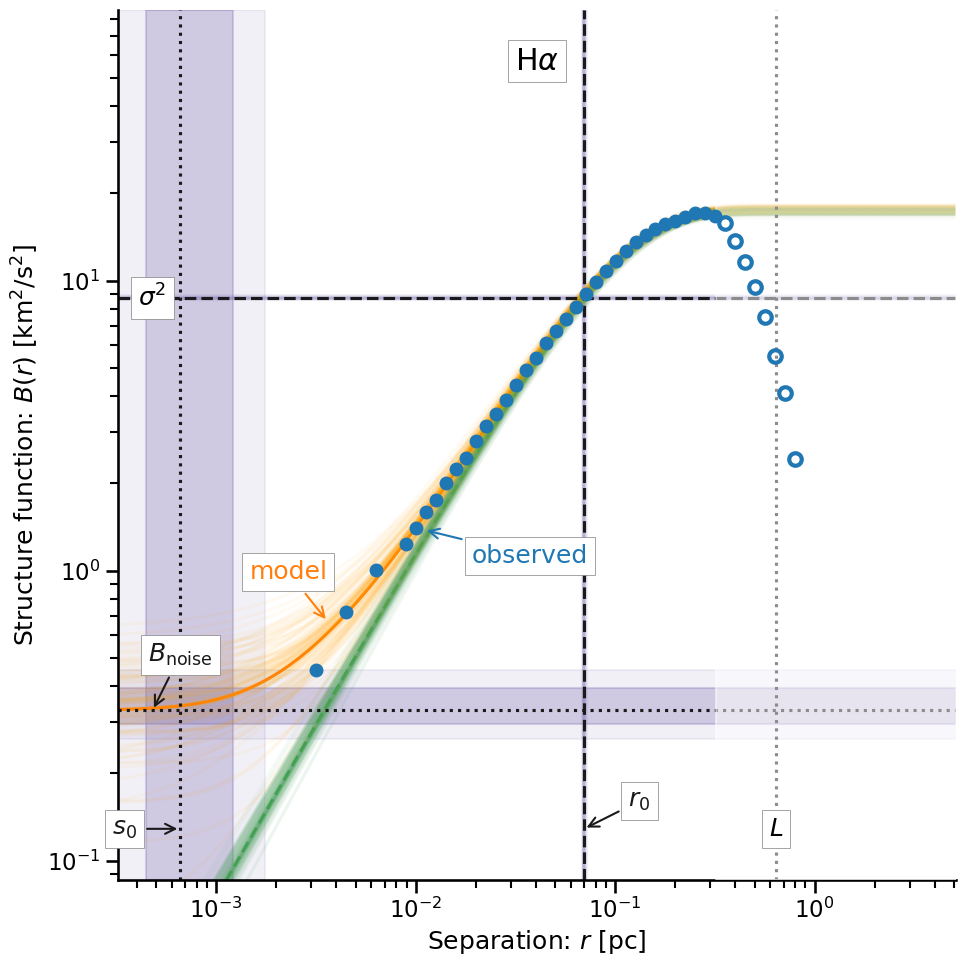

In [22]:
from astropy.table import Table

df_loaded = Table.read(fits_path, hdu="PARAMETERS").to_pandas()

bplot.STYLE["data label element"] = 4
bplot.STYLE["model label element"] = 0
bplot.STYLE["model label offset"] = (-60, 40)
bplot.STYLE["true model label element"] = 10
bplot.STYLE["true model label offset"] = (120, 60)

fig, ax = strucfunc_plot_from_params(
    df_loaded,
    r,
    B,
    to_fit,
    line,
    data,
    box_size,
    large_scale,
)